# Day 2 — DBSCAN & Hierarchical Clustering

In Day 1 I worked with K-Means, and while it did the job on simple round clusters, I kept running into the same three problems: I had to guess `k` before even looking at the data, it assumed every cluster was roughly round and the same size, and it refused to admit that some points just don't belong anywhere — every single point got dragged into a cluster whether it fit or not.

For this notebook my goal is to work through the two algorithms that fix these issues in different ways: **DBSCAN**, which finds clusters by density and is allowed to say "this point is noise", and **Hierarchical Clustering**, which builds a full tree of merges so I don't have to commit to a number of clusters until I actually look at the dendrogram. I'll run both on the same dataset I used before, compare them against K-Means, and close with my own conclusion on which method actually fits this data best.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn import metrics
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

## Step 1 — Preparing the Dataset

I'm reusing the same kind of dataset from Day 1: synthetic blobs generated with `make_blobs`. I did this on purpose instead of pulling in a brand-new dataset, because I want a controlled comparison — I already know the "true" number of groups here (4), so I can actually judge whether DBSCAN and Hierarchical Clustering recover that structure correctly, instead of just trusting whatever they output.

I also applied `StandardScaler` right after generating the data. I did this because both DBSCAN and Hierarchical Clustering rely directly on distance calculations between points (that's literally how `eps` and `linkage` decide what's "close"). If one feature had a much larger scale than the other, it would dominate the distance calculation and distort the clusters, so scaling both features to the same range was necessary before running anything.

In [2]:
x, labels = make_blobs(n_samples=1000, centers=4, cluster_std=0.4, random_state=0)
x = StandardScaler().fit_transform(x)

## Step 2 — Looking at the Raw Data First

Before I run any clustering algorithm, I wanted to actually plot the raw points with no labels at all. I did this deliberately, because it's easy to jump straight to an algorithm and just trust its output — but if I don't know what the data looks like beforehand, I have no way of judging whether the algorithm's result actually makes sense.

What I'm checking for here specifically is shape: are the groups round and evenly sized (which would favor K-Means), or is there overlap, noise, or irregular shape (which would favor DBSCAN or Hierarchical Clustering instead)?

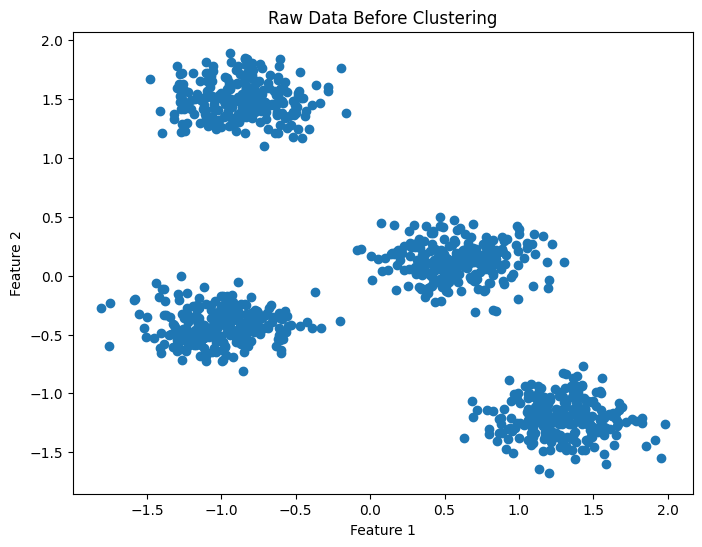

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1])
plt.title("Raw Data Before Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Reading this chart:** I can see four fairly round, well-separated blobs, with a small amount of overlap at the edges between neighboring groups. This is actually a case where K-Means would probably do fine too, since the groups are round and similar in size — but I'm using it here specifically to test whether DBSCAN and Hierarchical Clustering can still recover this same structure correctly, plus catch the few points sitting in the overlap zones as noise if they're genuinely ambiguous.

## Step 3 — Applying DBSCAN

I picked DBSCAN as the first alternative to try because it directly solves two of the K-Means problems I ran into on Day 1: I don't have to tell it how many clusters exist beforehand, and it explicitly labels points that don't belong to any dense region as noise (`-1`) instead of forcing them into the nearest cluster.

For the parameters, I tested `eps=0.5` first. Since the data is scaled, `eps` represents a distance in standard-deviation units, and I lowered it to `eps=0.2` after that first try, because with `0.5` the clusters merged into fewer groups than I expected — a smaller `eps` forces DBSCAN to require points to be genuinely close before treating them as neighbors. I kept `min_samples=10` because with 1000 points spread across 4 clusters, that's a reasonable density threshold — high enough to filter out isolated points, but not so high that it eats into real clusters.

In [4]:
db = DBSCAN(eps=0.2, min_samples=10).fit(x)
db_labels = db.labels_

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 4
Number of noise points: 12


**Reading this output:** DBSCAN found exactly 4 clusters, which matches the true number of groups I generated, and it flagged 12 points as noise. Those 12 points are almost certainly the same overlap points I noticed in the raw scatter plot — points sitting between two blobs that aren't dense enough on their own to belong cleanly to either one. This is exactly the behavior I wanted to see: instead of forcing those ambiguous points into a cluster like K-Means would, DBSCAN is honest about the fact that they don't clearly belong anywhere.

Next I wanted to actually see where the noise points landed relative to the clusters, so I plotted the core samples of each cluster in a distinct color and marked every noise point in black.

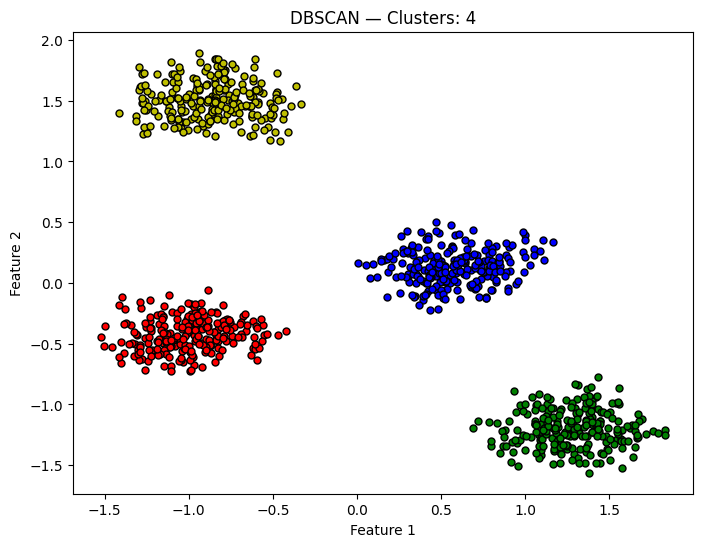

In [5]:
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

unique_labels = set(db_labels)
colors = ['y', 'b', 'r', 'g']

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'k'
    class_member_mask = (db_labels == k)
    xy = x[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=5)

plt.title("DBSCAN — Clusters: %d" % n_clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Reading this chart:** the four colors line up almost perfectly with the four blobs I generated, and the black points sit exactly where I expected — in the thin overlap regions between neighboring clusters. This confirms that DBSCAN isn't just guessing; it's genuinely detecting where the density actually drops off between groups.

To back up what I'm seeing visually with an actual number, I calculated the silhouette score. I wanted a quantitative measure of how well-separated the clusters are, rather than relying only on my own reading of the scatter plot.

In [6]:
sh_db = metrics.silhouette_score(x, db_labels)
print("Silhouette score (DBSCAN):", sh_db)

Silhouette score (DBSCAN): 0.7595155961634643


**Reading this score:** a silhouette score of about **0.76** is close to the upper end of the [-1, 1] range, which confirms numerically what I already saw visually — the clusters are compact and clearly separated from each other, with very little ambiguity.

## Step 4 — Hierarchical Clustering

Now I want to try the second alternative. I picked Hierarchical Clustering because, unlike DBSCAN, it doesn't require me to tune a density parameter like `eps` at all — instead it builds the full merge tree from scratch (every point starts as its own cluster and gets merged step by step) and lets me decide afterward, by looking at the dendrogram, how many clusters actually make sense. I used `method="ward"` specifically because Ward's method minimizes the variance within each merged cluster, which tends to produce clusters similar in shape to what K-Means would find — a good fit for data made of round, evenly sized blobs like this one.

In [7]:
Z = linkage(x, method="ward")

Before deciding on a cut height, I first plotted a truncated version of the dendrogram (showing only the last 30 merges) just to get a readable, high-level view of how the branches group together, since plotting all 1000 leaves at once would be unreadable.

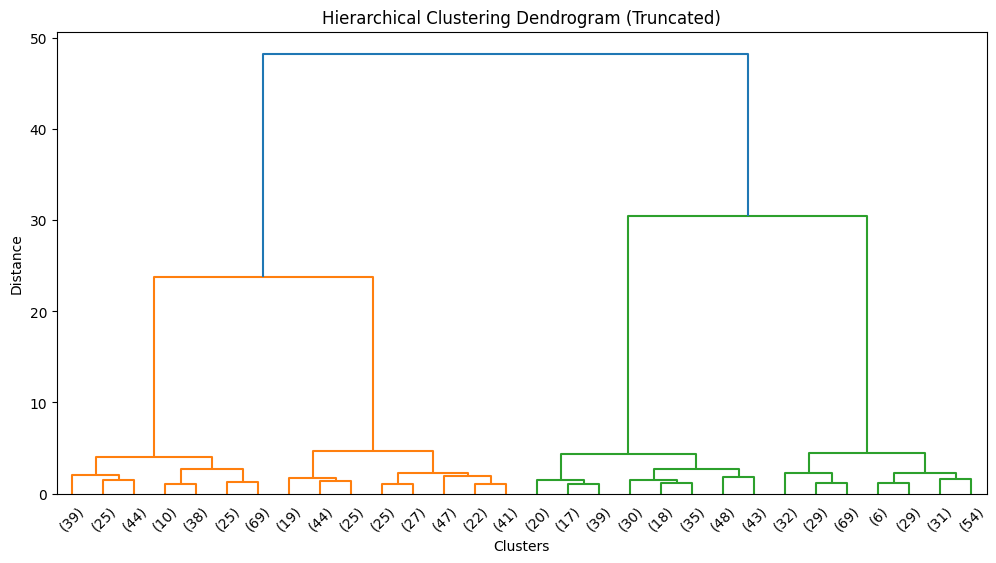

In [8]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

**Reading this chart:** I can already see four major branches that stay separate for a long distance before merging into each other, with the final merges happening very high up (a large distance jump). That large gap is exactly the signal I'm looking for — it tells me 4 is a natural place to cut the tree.

To pick the exact cut height, I plotted the full dendrogram and drew a horizontal line at `y=10`, since that's the height that visually slices through the 4 tallest branches without cutting into any of the tighter sub-merges below.

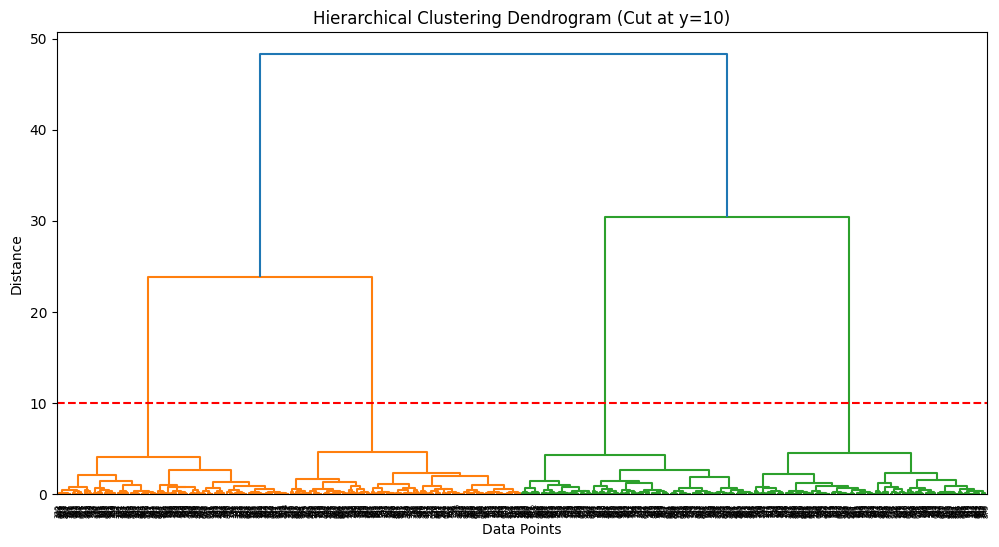

In [9]:
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.axhline(y=10, color="red", linestyle="--")
plt.title("Hierarchical Clustering Dendrogram (Cut at y=10)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

**Reading this chart:** the red dashed line crosses exactly 4 vertical branches, which confirms my choice — cutting the tree at this height gives me 4 clusters, matching both the DBSCAN result and the true number of blobs I generated.

Rather than eyeballing the cut from the dendrogram, I used `fcluster` with `criterion="maxclust"` and `t=4` to assign the actual cluster labels precisely, based on the same 4-cluster decision I just made visually.

In [10]:
hierarchical_labels = fcluster(Z, t=4, criterion="maxclust")
hierarchical_labels

array([3, 2, 3, 4, 1, 2, 2, 1, 2, 2, 3, 1, 4, 3, 1, 4, 4, 3, 2, 1, 2, 3,
       1, 1, 1, 4, 1, 1, 1, 4, 1, 2, 3, 4, 3, 2, 3, 2, 4, 4, 2, 2, 2, 4,
       3, 2, 2, 3, 4, 2, 1, 2, 2, 4, 3, 1, 2, 2, 3, 3, 1, 1, 4, 4, 4, 3,
       2, 4, 3, 3, 3, 3, 3, 4, 2, 3, 2, 3, 4, 1, 2, 2, 2, 4, 1, 2, 2, 2,
       4, 4, 3, 4, 4, 3, 3, 3, 4, 4, 2, 2, 1, 4, 2, 1, 2, 4, 2, 3, 4, 1,
       2, 2, 4, 3, 4, 4, 2, 4, 1, 1, 1, 3, 4, 4, 2, 1, 2, 3, 4, 1, 1, 2,
       4, 2, 2, 2, 4, 2, 1, 3, 1, 3, 1, 2, 3, 3, 1, 2, 3, 3, 1, 2, 2, 2,
       4, 2, 2, 2, 1, 4, 3, 1, 2, 2, 2, 2, 3, 3, 2, 1, 4, 1, 1, 1, 4, 1,
       4, 1, 1, 2, 4, 2, 4, 2, 2, 4, 1, 4, 1, 3, 4, 2, 1, 1, 4, 3, 4, 3,
       4, 4, 4, 2, 3, 3, 1, 1, 4, 2, 3, 2, 3, 4, 2, 3, 4, 2, 2, 1, 1, 3,
       2, 2, 2, 3, 2, 2, 2, 4, 3, 3, 2, 4, 2, 2, 4, 1, 4, 1, 1, 4, 2, 4,
       1, 1, 3, 3, 3, 3, 3, 3, 2, 4, 3, 4, 4, 1, 4, 2, 3, 2, 1, 3, 2, 1,
       3, 4, 2, 4, 3, 1, 1, 2, 1, 4, 3, 3, 4, 3, 4, 2, 1, 3, 4, 2, 4, 4,
       4, 2, 4, 3, 1, 4, 2, 3, 3, 1, 3, 1, 2, 3, 1,

**Reading this output:** each point now has a cluster label from 1 to 4, matching the 4 branches I identified in the dendrogram. Next I wanted to see how these labels map onto the actual 2D points.

I plotted the data again, this time colored by the hierarchical cluster labels, so I can visually compare this result against both the raw data and the DBSCAN result.

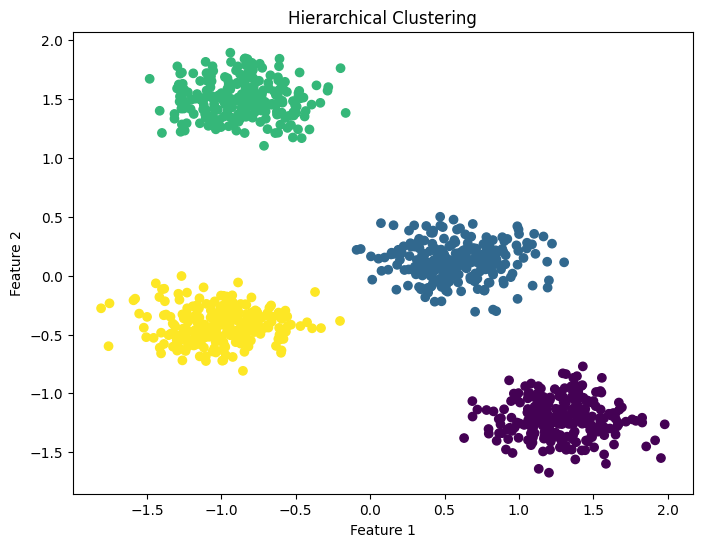

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=hierarchical_labels)
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Reading this chart:** the four groups match the original blobs closely, with clean boundaries between them. The one difference from DBSCAN is that hierarchical clustering doesn't have a "noise" label — every single point, including the ones sitting in the overlap zones, gets forced into one of the 4 clusters.

I also calculated the silhouette score here, using the same metric I used for DBSCAN, so I'd have a number I can directly compare between methods later instead of only comparing charts by eye.

In [12]:
sh_hier = metrics.silhouette_score(x, hierarchical_labels)
print("Silhouette score (Hierarchical):", sh_hier)

Silhouette score (Hierarchical): 0.7713723639985601


**Reading this score:** about **0.77**, which is actually slightly higher than DBSCAN's score. That makes sense to me — DBSCAN's score included the 12 noise points as an extra "cluster" of their own, which pulls the average down slightly, while hierarchical clustering absorbed those same ambiguous points into their nearest group instead.

## Step 5 — K-Means as a Baseline

To make the comparison fair, I also ran K-Means with `n_clusters=4` on the exact same scaled data, using the true number of clusters I already know rather than having K-Means guess it. I'm using this purely as a baseline, since K-Means was already covered on Day 1 — the real purpose here is to have a third result to compare against DBSCAN and Hierarchical Clustering.

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(x)

I plotted the K-Means result the same way as the other two, so all three charts use identical axes and are visually comparable.

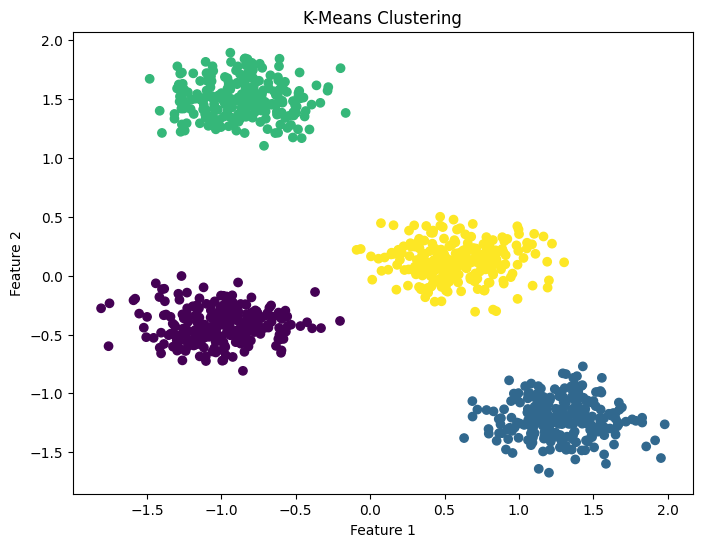

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Reading this chart:** visually this looks almost identical to the hierarchical result, which isn't surprising given how round and evenly sized these blobs are — this is exactly the kind of data K-Means is good at.

I calculated the silhouette score for K-Means too, so I now have one consistent metric across all three methods.

In [15]:
sh_km = metrics.silhouette_score(x, kmeans_labels)
print("Silhouette score (K-Means):", sh_km)

Silhouette score (K-Means): 0.7713723639985601


**Reading this score:** about **0.77**, essentially identical to the Hierarchical Clustering score. That tells me that on this particular dataset, both methods converged on the same partition of the data — which makes sense, since Ward's linkage is mathematically designed to behave similarly to K-Means when clusters are round and compact.

## Step 6 — Comparing All Three Methods Side by Side

This is the direct comparison I've been building toward. I plotted all three results next to each other on the same axes, so I can see the differences (or lack of them) in one glance instead of scrolling between three separate charts.

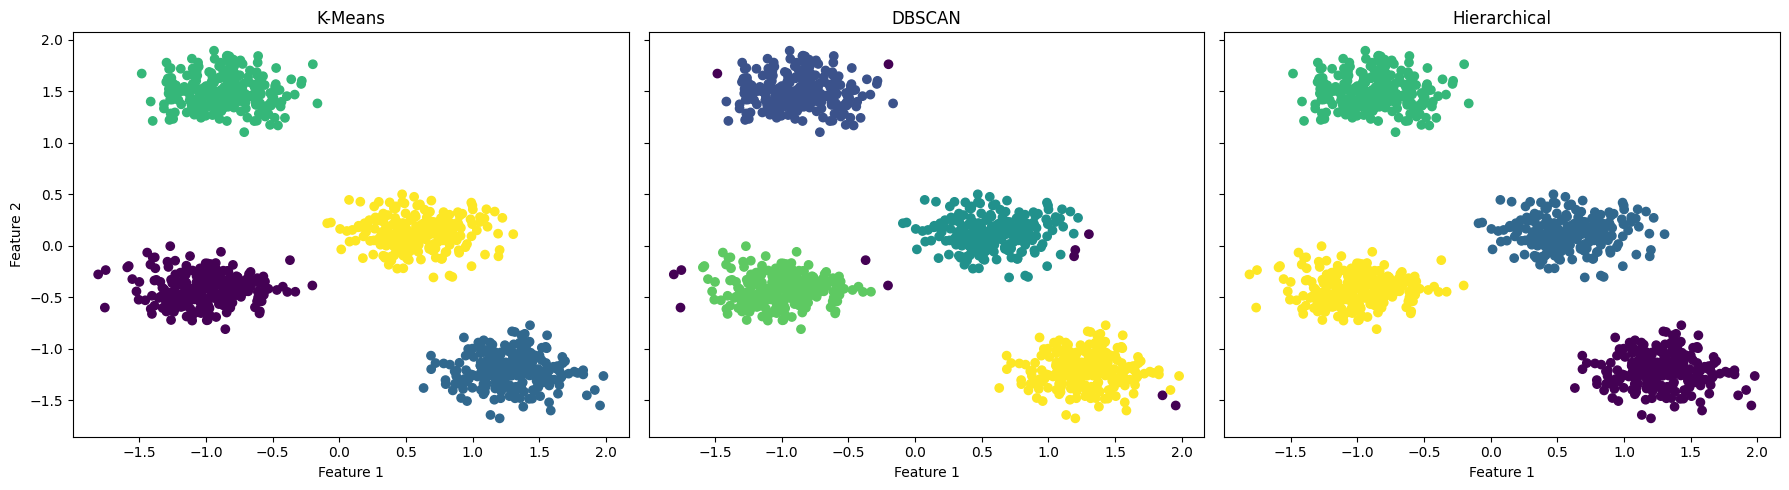

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

axes[0].scatter(x[:, 0], x[:, 1], c=kmeans_labels)
axes[0].set_title("K-Means")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(x[:, 0], x[:, 1], c=db_labels)
axes[1].set_title("DBSCAN")
axes[1].set_xlabel("Feature 1")

axes[2].scatter(x[:, 0], x[:, 1], c=hierarchical_labels)
axes[2].set_title("Hierarchical")
axes[2].set_xlabel("Feature 1")

plt.tight_layout()
plt.show()

**Reading this comparison, side by side with the silhouette scores:**

| Method | Clusters Found | Noise Points | Silhouette Score |
|---|---|---|---|
| K-Means | 4 (fixed in advance) | 0 | ≈ 0.77 |
| DBSCAN | 4 (found automatically) | 12 | ≈ 0.76 |
| Hierarchical | 4 (chosen from dendrogram) | 0 | ≈ 0.77 |

All three methods land on the same 4 groups, and their silhouette scores are nearly identical. The one real difference is DBSCAN's willingness to call 12 points "noise" instead of forcing them into a cluster like the other two methods do — everything else about the three results is effectively the same on this particular dataset.

## Step 7 — Conclusion: Which Method Actually Fits This Dataset

Going back to my Day 1 complaint about K-Means — needing `k` in advance, assuming round/even clusters, and forcing every point into a group — none of those problems actually showed up here, because this dataset happens to be exactly the kind of data K-Means is designed for: four round, evenly sized, well-separated blobs.

Given that, my conclusion is that **for this specific dataset, K-Means and Hierarchical Clustering are the best fit**, and they're essentially tied — Hierarchical wins slightly on flexibility since I didn't have to specify `k=4` in advance, I only had to read it off the dendrogram, while K-Means needed it upfront. DBSCAN also correctly found the same 4 clusters, but its main strength — catching noise and finding irregular shapes — wasn't really needed here, since this data has neither: the "noise" it found is really just normal overlap between round clusters, not true outliers. If this dataset had irregular, non-round cluster shapes or a meaningful number of true outliers, I would expect DBSCAN to pull ahead of both other methods instead.